In [1]:
import sys
import os
import pandas as pd

sys.path.append(os.path.abspath("../src"))

from preprocessing import (
    add_time_features,
    add_temperature_features,
    create_rain_target,
    create_snow_target
)

df = pd.read_csv("../data/raw/ghcn_daily_data.csv", parse_dates=["DATE"])

df = add_time_features(df)
df = add_temperature_features(df)
df = create_rain_target(df)
df = create_snow_target(df)
df = df.sort_values("DATE")

In [9]:
train = df[df["YEAR"] < 2025]
test = df[df["YEAR"] >= 2025]

features = [
    "TMAX",
    "TMIN",
    "TEMP_MEAN",
    "TEMP_RANGE",
    "SNOW"
]

X_train = train[features]
y_train = train["RAIN"]

X_test = test[features]
y_test = test["RAIN"]

In [10]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    max_depth=4,          # pequeño
    min_samples_leaf=20,  # evita ruido
    random_state=42
)

tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,20
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [4]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = tree.predict(X_test)

print("Matriz de confusión: \n", confusion_matrix(y_test, y_pred))
print("Reporte de clasificación: \n", classification_report(y_test, y_pred))

Matriz de confusión: 
 [[170  22]
 [ 41 132]]
Reporte de clasificación: 
               precision    recall  f1-score   support

           0       0.81      0.89      0.84       192
           1       0.86      0.76      0.81       173

    accuracy                           0.83       365
   macro avg       0.83      0.82      0.83       365
weighted avg       0.83      0.83      0.83       365



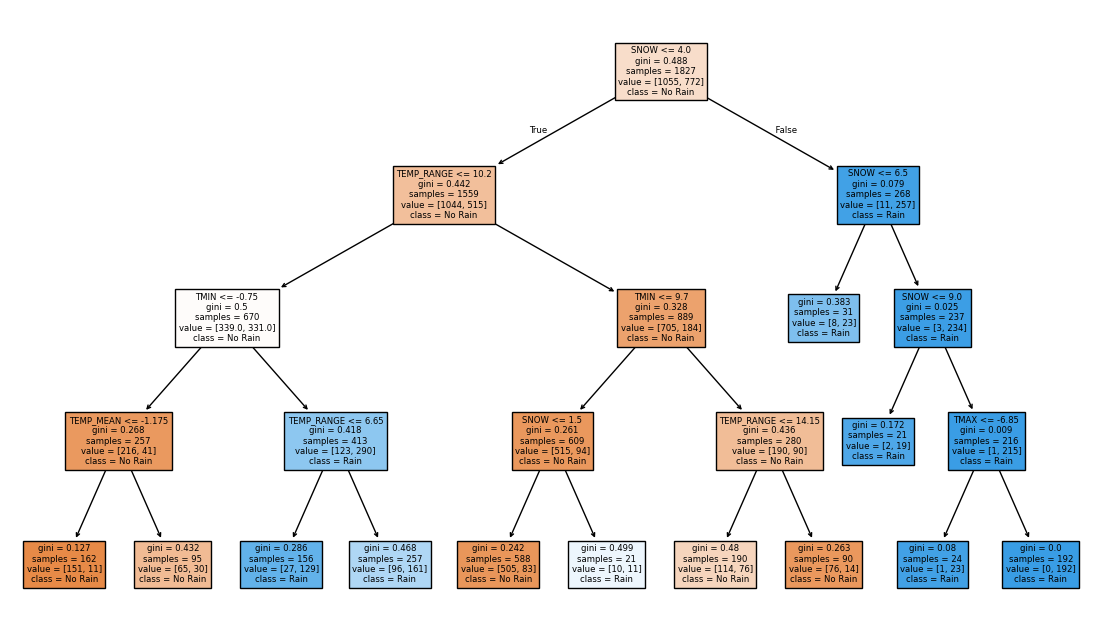

In [5]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))
plot_tree(
    tree,
    feature_names=features,
    class_names=["No Rain", "Rain"],
    filled=True
)
plt.show()

In [7]:
train = df[df["YEAR"] < 2025]
test = df[df["YEAR"] >= 2025]

features = [
    "TMAX",
    "TMIN",
    "TEMP_MEAN",
    "TEMP_RANGE",
]

X_train = train[features]
y_train = train["RAIN"]

X_test = test[features]
y_test = test["RAIN"]

In [8]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    max_depth=4,          # pequeño
    min_samples_leaf=20,  # evita ruido
    random_state=42
)

tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,20
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [18]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = tree.predict(X_test)

print("Matriz de confusión: \n", confusion_matrix(y_test, y_pred))
print("Reporte de clasificación: \n", classification_report(y_test, y_pred))

Matriz de confusión: 
 [[160  32]
 [ 92  81]]
Reporte de clasificación: 
               precision    recall  f1-score   support

           0       0.63      0.83      0.72       192
           1       0.72      0.47      0.57       173

    accuracy                           0.66       365
   macro avg       0.68      0.65      0.64       365
weighted avg       0.67      0.66      0.65       365



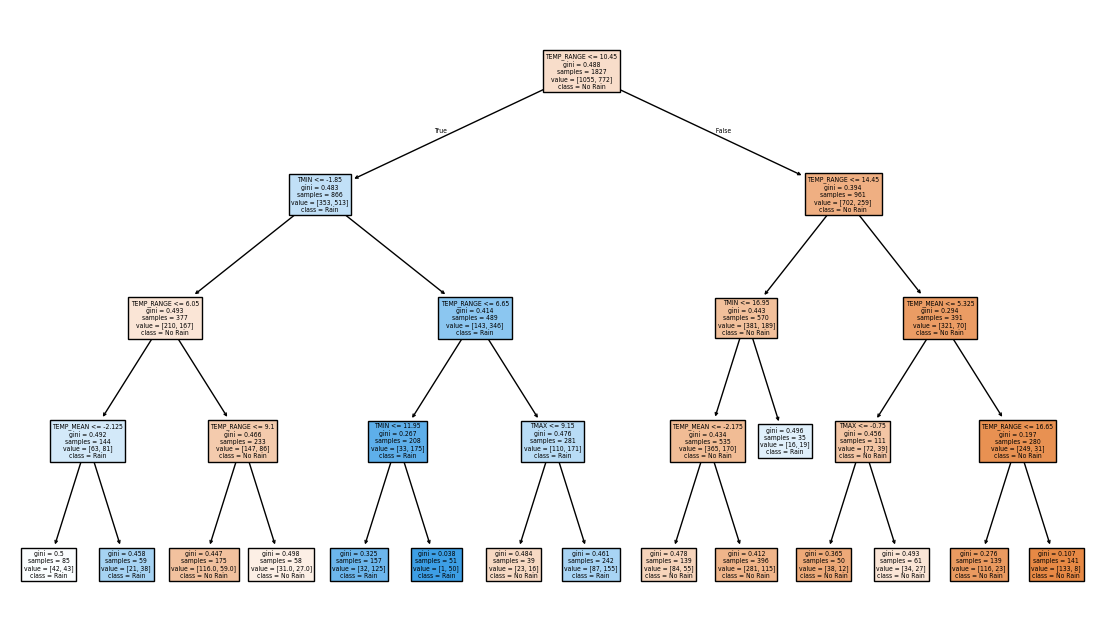

In [19]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))
plot_tree(
    tree,
    feature_names=features,
    class_names=["No Rain", "Rain"],
    filled=True
)
plt.show()